# Checking a FORM design point

Use the Strong Maximum Test to look for competing failure regions and examine what the diagnostic can miss.

**Before you start:** FORM and standard-normal design-point geometry.

## Problem and approach

FORM convergence does not establish that its design point represents every important failure region. The strong maximum test samples an enlarged sphere in independent standard-normal space and reports failure points outside the candidate's vicinity.

This tutorial checks a single half-space, detects a second failure region, visualizes the four point groups, and constructs a bounded region that the sphere misses. See the [theory](../theory.rst#theory-strong-maximum), [API guide](../strong_maximum.rst), and [OpenTURNS formulation](https://openturns.github.io/openturns/latest/theory/reliability_sensitivity/strong_maximum_test.html).

The test is a diagnostic, not a failure-probability estimator or a certificate of global optimality.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, t, expon
from scipy.integrate import quad


import pystra as ra


## Check a converged FORM design point

For $g=3-X$ with independent standard normals, FORM is exact. Its candidate is $(3,0)$, and every failure point on the test sphere lies in the candidate's vicinity.

In [2]:
model = ra.StochasticModel()
model.add_variable(ra.Normal("X", 0, 1))
model.add_variable(ra.Normal("Y", 0, 1))
form = ra.Form(stochastic_model=model, limit_state=ra.LimitState(lambda X, Y: 3 - X))
form.run()
check = ra.StrongMaximumTest(form, confidence_level=0.99, seed=2026)
check.run()
assert check.status == "no_competing_region_detected"
pd.Series(
    {
        "FORM beta": form.get_beta(),
        "FORM Pf": form.get_failure(),
        "Sphere points": check.point_number,
        "Radius": check.radius,
        "Nominal confidence": check.confidence_level,
        "Evaluations including origin and candidate": check.evaluation_count,
        "Status": check.status,
    }
)


FORM beta                                                              3.0
FORM Pf                                                            0.00135
Sphere points                                                           18
Radius                                                            4.730711
Nominal confidence                                                0.990313
Evaluations including origin and candidate                              20
Status                                        no_competing_region_detected
dtype: object

## Detect another failure region

Now take $g=9-X^2$. The candidate $(3,0)$ represents the right failure tail, but there is an equally important tail at $X<-3$. We supply this boundary point explicitly so the example does not depend on a local optimizer's initial direction. An explicit candidate must use the model's selected standard coordinates; the test checks a safe origin and boundary residual but does not optimize the candidate.

In [3]:
two_tail = ra.StrongMaximumTest(
    stochastic_model=model,
    limit_state=ra.LimitState(lambda X, Y: 9 - X**2),
    design_point=[3.0, 0.0],
    point_number=500,
    seed=2026,
)
two_tail.run()
assert two_tail.has_competing_points
print(two_tail.status)
print("One tangent half-space Pf:", norm.sf(3))
print("Exact two-tail Pf:", 2 * norm.sf(3))
pd.Series(
    {name: int(mask.sum()) for name, mask in two_tail.masks.items()},
    name="Sphere points",
)


competing_region_detected
One tangent half-space Pf: 0.0013498980316300933
Exact two-tail Pf: 0.0026997960632601866


far_failure     138
near_failure    141
far_safe        221
near_safe         0
Name: Sphere points, dtype: int64

The near/far split is $u\cdot(u^*/\beta)>\beta$. It is a geometric classification; raw magnitudes of $g$ cannot rank importance because positive rescaling changes the values without changing the failure event.

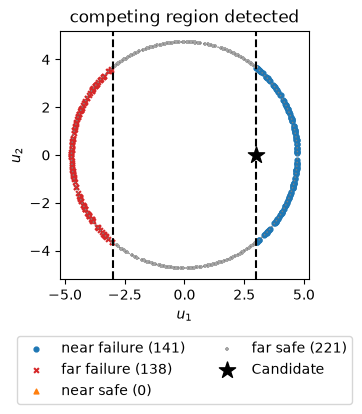

First physical restart candidates:
 [[-4.5270396   1.3731495 ]
 [-3.80994576  2.8042718 ]
 [-3.38890103  3.30075399]
 [-3.61517294 -3.05125412]
 [-3.98398312 -2.55098129]]


In [4]:
fig, ax = ra.plotting.plot_strong_maximum(two_tail)
ax.axvline(3, color="black", linestyle="--")
ax.axvline(-3, color="black", linestyle="--")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2)
plt.show()
competing_x = two_tail.get_points("far_failure", uspace=False)
assert np.all(competing_x[:, 0] < -3)
print("First physical restart candidates:\n", competing_x[:5])


**Figure.** Sphere samples for the two-tail limit state include failure points far from the supplied positive design point, revealing the competing negative tail.

## Understand confidence and cost

`importance_level` is a normal-density ratio $\varepsilon$, and `accuracy_level` is a sphere enlargement factor $\tau>1$. Neither is a tolerance on FORM's probability error. The nominal confidence is the probability of hitting a reference spherical cap of the specified size with independent samples.

The required count grows with dimension. Construction computes the budget before any limit-state evaluations; `max_points` rejects an oversized request. PySTRA rounds the count upward to meet the requested nominal confidence.

In [5]:
budgets = []
for dimension in [2, 5, 10, 20]:
    m = ra.StochasticModel()
    for i in range(dimension):
        m.add_variable(ra.Normal(f"X{i}", 0, 1))
    diagnostic = ra.StrongMaximumTest(
        stochastic_model=m,
        limit_state=ra.LimitState(lambda **x: 3 - x["X0"]),
        design_point=[3.0] + [0.0] * (dimension - 1),
        importance_level=0.15,
        accuracy_level=3,
        confidence_level=0.99,
        max_points=1_000_000,
        seed=2026,
    )
    budgets.append(
        {
            "Dimension": dimension,
            "Sphere points": diagnostic.point_number,
            "Cap probability": diagnostic.cap_probability,
            "Nominal confidence": diagnostic.confidence_level,
        }
    )
pd.DataFrame(budgets)


,Dimension,Sphere points,Cap probability,Nominal confidence
0,2,18,0.227101,0.990313
1,5,111,0.040987,0.990395
2,10,1297,0.003547,0.990033
3,20,125521,0.000037,0.990000


## A bounded failure island the sphere cannot detect

Add a small circular failure island centred at $(-2,0)$ with radius 0.2:

$$g(u)=\min\{3-u_1,(u_1+2)^2+u_2^2-0.2^2\}.$$

The origin remains safe. The island's nearest boundary is at radius 1.8, closer than the candidate at radius 3. But the entire island lies inside the sampled sphere, so no number of samples **on that sphere** can find it. A negative test therefore cannot certify the candidate.

Diagnostic: no_competing_region_detected
Known missed failure point: (-2, 0); candidate: (3, 0)


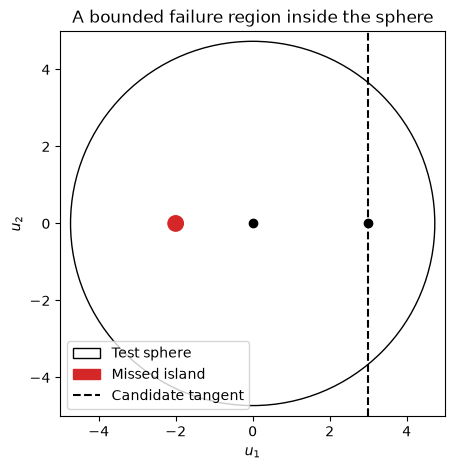

In [6]:
def island_lsf(X, Y):
    return np.minimum(3 - X, (X + 2) ** 2 + Y**2 - 0.2**2)


island_check = ra.StrongMaximumTest(
    stochastic_model=model,
    limit_state=ra.LimitState(island_lsf),
    design_point=[3.0, 0.0],
    point_number=500,
    seed=2026,
)
island_check.run()
assert island_check.radius > 2.2
assert island_lsf(-2, 0) < 0
assert island_check.status == "no_competing_region_detected"
print("Diagnostic:", island_check.status)
print("Known missed failure point: (-2, 0); candidate: (3, 0)")
fig, ax = plt.subplots(figsize=(5, 5))
ax.add_patch(plt.Circle((0, 0), island_check.radius, fill=False, label="Test sphere"))
ax.add_patch(plt.Circle((-2, 0), 0.2, color="tab:red", label="Missed island"))
ax.axvline(3, color="black", linestyle="--", label="Candidate tangent")
ax.scatter([0, 3], [0, 0], color="black")
ax.set(
    xlim=(-5, 5),
    ylim=(-5, 5),
    xlabel="$u_1$",
    ylabel="$u_2$",
    title="A bounded failure region inside the sphere",
)
ax.set_aspect("equal")
ax.legend(loc="lower left")
plt.show()


**Figure.** A small circular failure island lies inside the test sphere and does not intersect it. Sphere sampling therefore misses this bounded failure region.

## Apply the diagnostic to system components

System FORM already accounts for distinct component tangent planes. Apply the test separately to the retained component `Form` objects to look for additional regions within each component. These checks do not validate the whole system probability. Non-Gaussian copulas must use normal Rosenblatt coordinates for the current test.

In [7]:
system = ra.SeriesSystem(
    [ra.Component("a", lambda X: 3 - X), ra.Component("b", lambda Y: 3 - Y)]
)
system_form = ra.SystemFORM(system, model)
system_form.run()
checks = {}
for name, component_form in system_form.component_results.items():
    diagnostic = ra.StrongMaximumTest(component_form, point_number=200, seed=2026)
    diagnostic.run()
    checks[name] = diagnostic
assert all(not item.has_competing_points for item in checks.values())
pd.Series(
    {name: item.status for name, item in checks.items()}, name="Component diagnostic"
)


a    no_competing_region_detected
b    no_competing_region_detected
Name: Component diagnostic, dtype: str

Far failure points can guide additional design-point searches; they are not already optimized design points. Inspect all four groups, vary the sphere geometry when appropriate, and compare with original-event simulation. A fresh instance with the same seed reproduces its samples; rerunning an instance advances its local generator.

## Interpretation

Far-failure points are candidates for restarting FORM. A test with no detected competitors does not establish that small bounded failure regions are absent.

**Continue:** [User guide](../strong_maximum.rst) · [API reference](../api/reliability.rst) · [Theory](../theory/design_point_methods.rst)